In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import shap
import torch.nn.functional as F

import matplotlib.pyplot as plt
import plotly.express as px

import huggingface_hub
from transformers import Wav2Vec2Model
import os
from dotenv import load_dotenv
import random
from tqdm import tqdm
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from collections import OrderedDict
import soundfile as sf
import librosa


# from transformers import Wav2Vec2Model

from scipy.optimize import brentq
from scipy.interpolate import interp1d

from huggingface_hub import hf_hub_download

In [2]:
load_dotenv()
hf_auth=os.getenv("hf_auth")

device=torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
class Wav2Vec2Deepfake(nn.Module):

    def __init__(self):
        super().__init__()
        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base",
            use_safetensors=True
        )
        hidden_size = (
            self.wav2vec.config.hidden_size
        )
        for param in self.wav2vec.parameters():

            param.requires_grad = False
        for layer in self.wav2vec.encoder.layers[-2:]:

            for param in layer.parameters():

                param.requires_grad = True

        self.classifier = nn.Sequential(

            nn.Linear(hidden_size, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 2)
        )

    def forward(self, x):

        outputs = self.wav2vec(
            x
        )

        hidden_states = (
            outputs.last_hidden_state
        )

        pooled = hidden_states.mean(
            dim=1
        )

        logits = self.classifier(
            pooled
        )

        return logits

In [4]:
# import Wav2Vec Model from HuggingFace

# issues with HF security flags, but no cuda 12.1 support for pytorch 2.6 as directed
import os
os.environ["TRANSFORMERS_NO_SAFE_LOAD"] = "1"


In [5]:

w2v_model=Wav2Vec2Deepfake()
wav2vec_name='best_model.pth'
w2v_checkpoint=hf_hub_download(
    repo_id='rde6mn/no_aug_w2v_4s',
    filename=wav2vec_name
)
w2v_checkpoint=torch.load(w2v_checkpoint, map_location=device)
state_dict=w2v_checkpoint["model_state_dict"]

w2v_model.load_state_dict(state_dict)
w2v_model.eval()

# w2v parameters
SR = 16000
MAX_LEN = 4 * SR
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-5
NUM_WORKERS = 4

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
audiofile_dir=r"G:\My Drive\ASVSpoof_Data\unzipped2019\LA\LA\ASVspoof2019_LA_eval\flac"
audiofiles=glob.glob(os.path.join(audiofile_dir, "*.flac"))

def process_audio(audio_path):
    try:
        waveform, sr = sf.read(audio_path)
        if len(waveform.shape) > 1:
            waveform = waveform.mean(axis=1)

        if sr != SR:
            waveform = librosa.resample(
                waveform,
                orig_sr=sr,
                target_sr=SR
            )
    except Exception as e:
        try:
            waveform, sr = librosa.load(
                audio_path,
                sr=SR,
                mono=True
            )
        except Exception as e2:
            print(f"FAILED TO LOAD: {audio_path}")
            return None
    if len(waveform) > MAX_LEN:
        waveform = waveform[:MAX_LEN]
    else:
        waveform = np.pad(
            waveform,
            (0, MAX_LEN - len(waveform))
        )
    waveform = torch.tensor(
        waveform
    ).float()

    return waveform

In [14]:
waveforms=[]

# Preprocess the waveforms
for file in audiofiles:
    audio_path=file
    waveform=process_audio(audio_path)
    if waveform is not None:
        waveforms.append(waveform)
        if len(waveforms)==100:
                break
    else:
        print(f"FAILED TO LOAD: {audio_path}")
    


In [9]:
paths=audiofiles[:100]
filenames=[]
for path in paths:
    filename=os.path.basename(path)
    filenames.append(filename)

    
protocol=pd.read_csv(r"G:\My Drive\ASVSpoof_Data\unzipped2019\LA\LA\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.eval.trl.txt", header=None, sep=' ')
# protocol=protocol.rename(columns={0: 'LA_ID', 1: 'LA_E_NUM', 3: 'Source', 4: 'Label'}, inplace=True)
protocol.sample(5)

,0,1,2,3,4
60656,LA_0019,LA_E_3511531,-,A07,spoof
298,LA_0048,LA_E_2968037,-,A12,spoof
69940,LA_0029,LA_E_1930371,-,A08,spoof
37086,LA_0019,LA_E_5016775,-,-,bonafide
2766,LA_0055,LA_E_6136041,-,-,bonafide


In [15]:
def make_spectrogram(waveform, sr=SR):
    # Compute the spectrogram
    S = librosa.stft(waveform.numpy())
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    # Plot the spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')
    plt.tight_layout()
    plt.show()

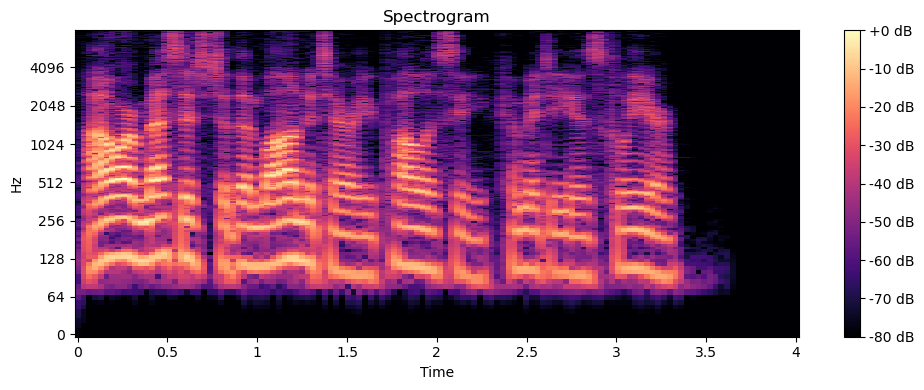

In [16]:
make_spectrogram(waveforms[20])

In [17]:
def predict_fn(waveform):
    with torch.no_grad():
        if isinstance(waveform, np.ndarray):
            waveform = torch.from_numpy(waveform).float()
        if waveform.dim() == 1:
            waveform=waveform.unsqueeze(0)

        outputs = w2v_model(waveform)
        probs = torch.softmax(outputs, dim=1)
        preds = (probs >= 0.5).long()
        return probs.numpy()

def pred_prob(waveform):
    with torch.no_grad():
        if isinstance(waveform, np.ndarray):
            waveform = torch.from_numpy(waveform).float()
        if waveform.dim() == 1:
            waveform=waveform.unsqueeze(0)

        outputs = w2v_model(waveform)
        probs = torch.softmax(outputs, dim=1)
        preds = (probs >= 0.5).long()
        return probs, preds

In [18]:
# Wrap the Wav2Vec model 
class ShapWav2VecWrapper:
    def __init__(self, model, waveform, num_segments=200, device=device):
        self.model = model.to(device)
        self.model.eval()
        self.device = device

        self.waveform = waveform.squeeze().cpu().numpy()
        self.num_segments = num_segments

        # Segment boundaries
        self.segment_length = len(self.waveform) // num_segments
        self.segments = [
            (i * self.segment_length, (i + 1) * self.segment_length)
            for i in range(num_segments)
        ]

    def apply_mask(self, mask):
        """Reconstruct waveform by zeroing out masked segments."""
        masked_waveform = self.waveform.copy()
        for i, m in enumerate(mask):
            if m == 0:
                start, end = self.segments[i]
                masked_waveform[start:end] = 0.0
        return masked_waveform

    def __call__(self, masks):
        """SHAP will call this with many masks."""
        outputs = []
        for mask in masks:
            masked_waveform = self.apply_mask(mask)

            # Convert to tensor [1, T]
            x = torch.tensor(masked_waveform, dtype=torch.float32).unsqueeze(0).to(self.device)

            with torch.no_grad():
                logits = self.model(x)
                probs = F.softmax(logits, dim=1).cpu().numpy()

            outputs.append(probs[0])

        return np.array(outputs)

In [19]:
waveform = waveforms[25] 

wrapper = ShapWav2VecWrapper(
    model=Wav2Vec2Deepfake(),
    waveform=waveform,
    num_segments=20,
    device=device
)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:

# Generate baseline masks as background for SHAP
background = np.zeros((10, wrapper.num_segments)) 

explainer = shap.KernelExplainer(wrapper, background)
shap_values = explainer.shap_values(
    np.ones((1, wrapper.num_segments)),  # full-signal mask
    nsamples=20
)



  0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
print(type(shap_values))
print(len(shap_values))
print(np.array(shap_values).shape)


<class 'numpy.ndarray'>
1
(1, 20, 2)


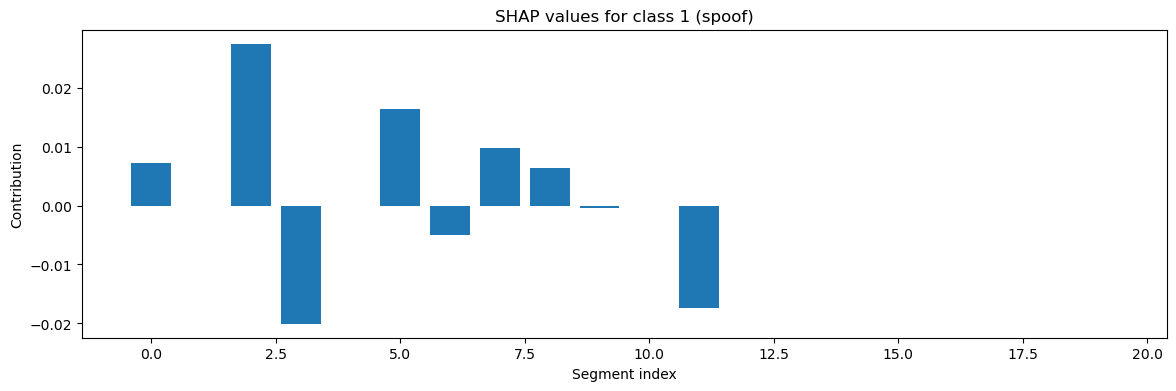

In [22]:

vals = shap_values[0][:, 1]

plt.figure(figsize=(14, 4))
plt.bar(np.arange(wrapper.num_segments), vals)
plt.title("SHAP values for class 1 (spoof)")
plt.xlabel("Segment index")
plt.ylabel("Contribution")
plt.show()

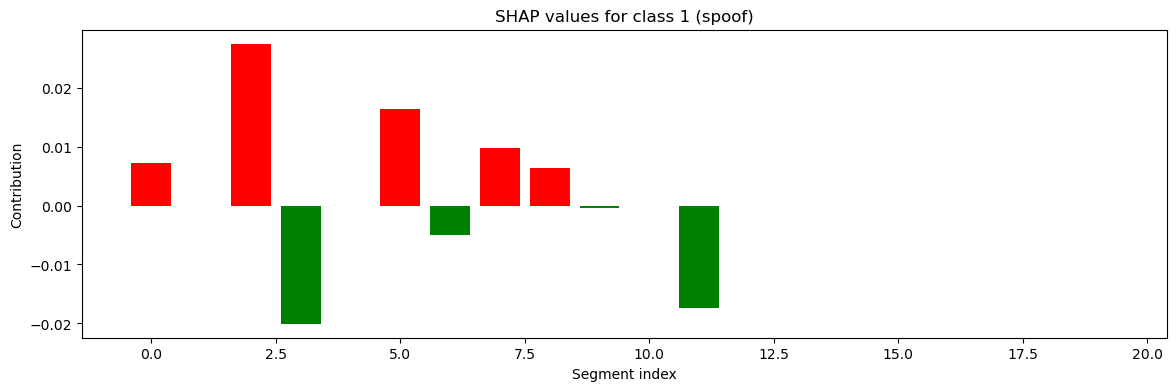

In [23]:
vals = shap_values[0][:, 1]  # class 1 (spoof)

plt.figure(figsize=(14, 4))
colors = ['red' if v > 0 else 'green' for v in vals]

plt.bar(np.arange(wrapper.num_segments), vals, color=colors)
plt.title("SHAP values for class 1 (spoof)")
plt.xlabel("Segment index")
plt.ylabel("Contribution")
plt.show()


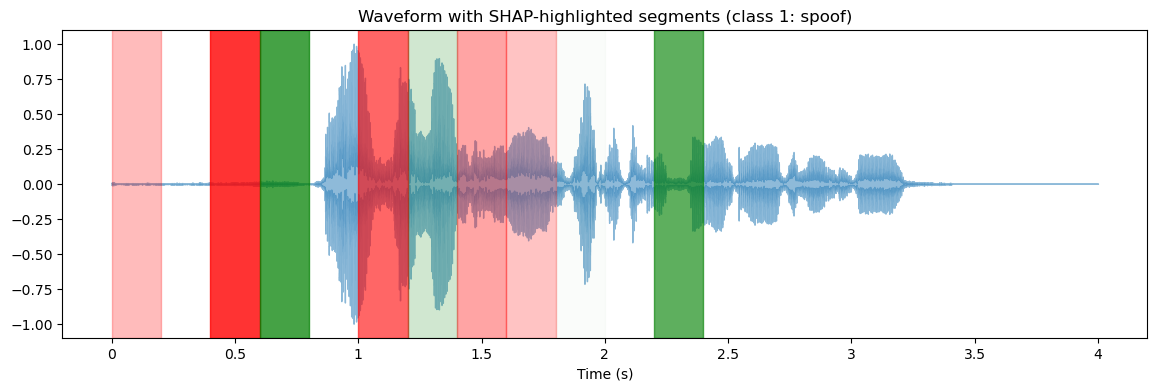

In [24]:
import librosa
import librosa.display

wave = wrapper.waveform
segment_len = len(wave) // wrapper.num_segments
vals = shap_values[0][:, 1]

plt.figure(figsize=(14, 4))
librosa.display.waveshow(wave, sr=16000, alpha=0.5)

for i, v in enumerate(vals):
    start = i * segment_len
    end = (i+1) * segment_len
    color = 'red' if v > 0 else 'green'
    plt.axvspan(start/16000, end/16000, color=color, alpha=min(abs(v)/max(abs(vals)), 0.8))

plt.title("Waveform with SHAP-highlighted segments (class 1: spoof)")
plt.xlabel("Time (s)")
plt.show()


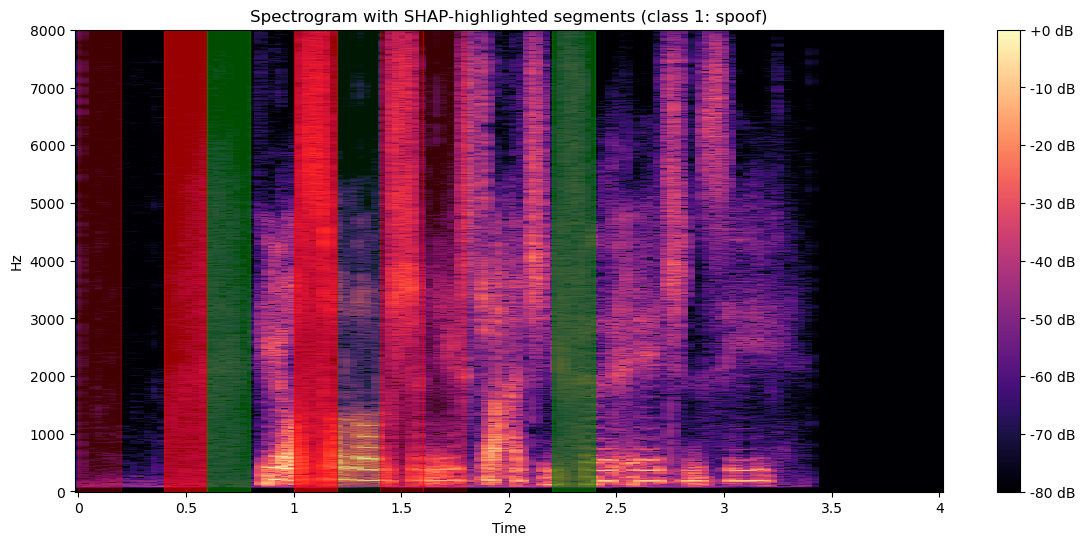

In [25]:
import librosa
import librosa.display

wave = wrapper.waveform
vals = shap_values[0][:, 1]
segment_len = len(wave) // wrapper.num_segments

S = librosa.amplitude_to_db(np.abs(librosa.stft(wave)), ref=np.max)

plt.figure(figsize=(14, 6))
librosa.display.specshow(S, sr=16000, x_axis='time', y_axis='hz', cmap='magma')

for i, v in enumerate(vals):
    start = i * segment_len / 16000
    end = (i+1) * segment_len / 16000
    color = 'red' if v > 0 else 'green'
    plt.axvspan(start, end, color=color, alpha=min(abs(v)/max(abs(vals)), 0.6))

plt.title("Spectrogram with SHAP-highlighted segments (class 1: spoof)")
plt.colorbar(format='%+2.0f dB')
plt.show()


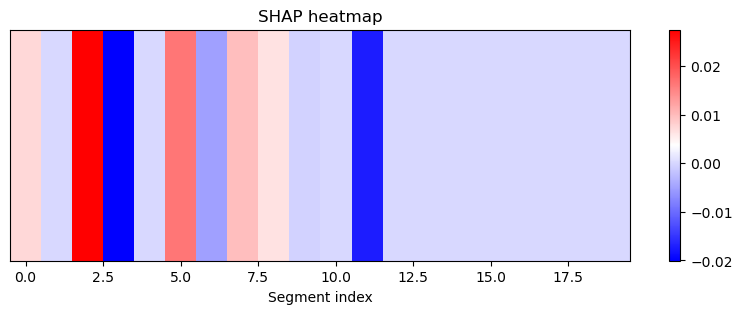

In [29]:
plt.figure(figsize=(10, 3))
plt.imshow(vals.reshape(1, -1), cmap='bwr', aspect='auto')
plt.colorbar()
plt.title("SHAP heatmap")
plt.yticks([])
plt.xlabel("Segment index")
plt.show()


In [35]:
# Librosa Feature Extraction
def extract_AudioFeatures(waveform, sr=20):
    y= waveform.numpy()
    # Onset Envelope for Librosa functions
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    
    # Rhythm
    #temp_ratio=librosa.tempo_frequencies(y=y, sr=sr, onset_envelope=onset_env)
    
    # Spectral Flatness
    flatness=librosa.feature.spectral_flatness(y=y)

    # Mel-Frequency Cepstral Coefficients (MFCCs)
    mfccs=librosa.feature.mfcc(y=y, sr=sr)

    # Harmonic-Percussive Source Separation (HPSS)
    hpss=librosa.effects.hpss(y)

    # Return Features Labelled
    #print(f"Tempo Ratio: {temp_ratio}")
    print(f"Flatness: {flatness}")
    print(f"MFCCs: {mfccs}")
    print(f"HPSS: {hpss}")
    return flatness, mfccs, hpss

extract_AudioFeatures(waveform)

Flatness: [[3.99859577e-01 1.77789018e-01 2.72765122e-02 6.68074116e-02
  3.52743901e-02 2.84688715e-02 2.95253955e-02 2.97146011e-02
  2.44041849e-02 2.31474079e-02 2.17433684e-02 2.62306780e-02
  1.44302137e-02 3.05544790e-02 5.77602386e-02 7.88629502e-02
  1.08275943e-01 1.37858406e-01 1.54154941e-01 1.61887571e-01
  1.87323660e-01 1.69314504e-01 1.33962691e-01 1.04462817e-01
  8.47762600e-02 1.48447290e-01 1.00413980e-02 2.47327727e-03
  1.22956338e-03 1.26538682e-03 9.77118383e-04 5.05783304e-04
  4.28873021e-03 2.60519721e-02 8.77173766e-02 1.08586356e-01
  1.78649817e-02 1.20761001e-03 2.47561140e-04 2.72595702e-04
  3.67892382e-04 2.49023869e-04 9.77326054e-05 1.55592599e-04
  2.15748465e-03 5.43696396e-02 1.78560793e-01 1.23908103e-01
  1.29510313e-01 4.13572975e-02 1.42227521e-03 1.49079147e-04
  2.09204256e-04 2.95050617e-04 4.09494358e-04 1.02084912e-02
  1.08865246e-01 2.55740792e-01 2.54020452e-01 6.31736517e-02
  1.50247468e-02 8.83761700e-03 2.25880705e-02 1.78850871e-0

(array([[3.99859577e-01, 1.77789018e-01, 2.72765122e-02, 6.68074116e-02,
         3.52743901e-02, 2.84688715e-02, 2.95253955e-02, 2.97146011e-02,
         2.44041849e-02, 2.31474079e-02, 2.17433684e-02, 2.62306780e-02,
         1.44302137e-02, 3.05544790e-02, 5.77602386e-02, 7.88629502e-02,
         1.08275943e-01, 1.37858406e-01, 1.54154941e-01, 1.61887571e-01,
         1.87323660e-01, 1.69314504e-01, 1.33962691e-01, 1.04462817e-01,
         8.47762600e-02, 1.48447290e-01, 1.00413980e-02, 2.47327727e-03,
         1.22956338e-03, 1.26538682e-03, 9.77118383e-04, 5.05783304e-04,
         4.28873021e-03, 2.60519721e-02, 8.77173766e-02, 1.08586356e-01,
         1.78649817e-02, 1.20761001e-03, 2.47561140e-04, 2.72595702e-04,
         3.67892382e-04, 2.49023869e-04, 9.77326054e-05, 1.55592599e-04,
         2.15748465e-03, 5.43696396e-02, 1.78560793e-01, 1.23908103e-01,
         1.29510313e-01, 4.13572975e-02, 1.42227521e-03, 1.49079147e-04,
         2.09204256e-04, 2.95050617e-04, 4.09494358